#Part 1 (Reading Assignment), 20 points

**Reminder: there are 5 reading assignments, 3% each for 15% total of your final grade.**

The reading assignment consists of two papers - [one on alignment before fusion](https://arxiv.org/abs/2107.07651), and one on the [Platonic Representation Hypothesis](https://arxiv.org/pdf/2405.07987). Read both papers and then answer the following questions:

1. Explain the implications of 'align before fuse' on your tasks of interest. at which degree, and what type of fusion needs to be performed? And what level of alignment would you need to perform for your data, so that subsequent fusion or representation learning is successful?
2. How can you perform controlled experiments to validate the types of fusion and/or alignment needed for your tasks? What are some challenges you foresee in fusing and aligning your data?
3. Explain the implications of 'platonic representation hypothesis' on your tasks of interest. Do you believe alignment between modalities would automatically emerge as models trained on your data are scaled up?
4. What are some reasons why alignment would not emerge i.e., counter-arguments to the platonic representation hypothesis? You are encouraged to search for follow-up works to the original paper that both support and counter the original arguments.
5. What experiments would you propose to validate the existence and emergence of alignment in your tasks?
6. Can you also think of some downsides of strongly (or perfectly) aligning your data modalities? How can you design experiments to validate that these risks are not present in your trained models?

### Reading Assignment Answers

**1. Implications of "Align Before Fuse" on our comfort prediction task:**

For predicting comfort from video (visual frames + text transcripts), alignment before fusion is critical because our modalities operate at different temporal granularities: visual frames at ~1 fps and text at the word level. The "align before fuse" principle (Li et al., 2021) suggests that before any fusion (whether early concatenation or tensor product), we must first align modality elements -- e.g., mapping each frame to the corresponding spoken words via timestamp alignment. Without this, fusion would combine misaligned features, injecting noise. For our data, we need **temporal alignment** at the segment level (using SDK timestamps) before applying any fusion technique. A moderate level of fusion (intermediate/late) is most appropriate given the semantic gap between pixel-level visual features and word-level text embeddings.

**2. Controlled experiments to validate fusion/alignment:**

We can run ablation studies: (a) train with no alignment (random pairing of frames and text), (b) segment-level alignment (SDK timestamps), and (c) learned attention-based alignment. Comparing accuracy across these conditions isolates the effect of alignment quality. Challenges include: temporal granularity mismatch (30 fps frames vs. variable-rate words), the small dataset size (26 videos) limiting statistical power, and the fact that video-level text averaging loses word order.

**3. Platonic Representation Hypothesis implications:**

The Platonic Representation Hypothesis (Huh et al., 2024) posits that neural networks trained on different data modalities converge toward a shared statistical model of reality. For comfort prediction, this would mean that a sufficiently large vision model and a sufficiently large language model, trained independently, would develop representations where "comfortable" visual patterns (smiling, relaxed posture) and "comfortable" text patterns (positive words, calm tone descriptions) naturally align. We are somewhat skeptical this would fully emerge for our task -- comfort is a subjective, culturally nuanced concept that may not be captured by purely statistical convergence.

**4. Counter-arguments to the Platonic Representation Hypothesis:**

Several counter-arguments exist: (a) **Modality-specific information**: visual micro-expressions and prosodic cues encode comfort signals that have no text analog, so perfect alignment would lose this unique information. (b) **Task specificity**: The hypothesis was demonstrated on broad semantic tasks (image-text retrieval), but specialized tasks like comfort detection may require modality-specific features that diverge rather than converge. (c) **Data distribution bias**: Models trained on internet data may converge on internet-centric representations that don't transfer to niche domains. Follow-up work by Thrush et al. (2024) showed that representation convergence depends heavily on training data diversity and may not hold for low-resource domains.

**5. Experiments to validate alignment emergence:**

We propose: (a) Train separate visual and text encoders on our dataset at increasing scales, then measure representation similarity using CKA (Centered Kernel Alignment) between visual and text embeddings for matched comfort labels. (b) Perform linear probing: train a linear classifier on frozen visual embeddings to predict text embedding clusters, and vice versa. If alignment emerges, cross-modal linear probing accuracy should increase with model scale. (c) Measure zero-shot transfer: use a model trained only on visual features to classify text-derived comfort labels.

**6. Downsides of strong alignment:**

Perfect alignment could cause **modality collapse** -- where the model ignores modality-specific information by projecting everything into a shared space. For comfort prediction, visual micro-expressions and text sentiment carry complementary (not redundant) signals; collapsing them would lose information. Another risk is **hallucination amplification**: if visual and text representations are perfectly aligned, errors in one modality could reinforce errors in the other. To validate these risks aren't present, we can: (a) measure mutual information between each modality's private representation and the aligned representation, (b) run single-modality ablations to ensure multimodal models still outperform unimodal ones (indicating the model uses both modalities, not just the aligned component), and (c) test robustness by corrupting one modality and checking if the other compensates.

#Part 2 (Homework Assignment), 100 points

**Reminder: there are 5 homework assignments, 7% each for 35% total of your final grade.**

For this assignment, we will finally begin playing with some of the concepts discussed in the class regarding multimodal modeling.

The first part will deal with Einsum and Tensors.

# Problem 1: Tensors (5 points)

(5 pts) Let's start with tensors. A tensor represents an N-th dimensional array of numbers. In machine learning, they are used to represent data as they can efficiently represent complex data to train with. We traditionally use PyTorch as the package of choice to work with tensors. Fill in the code below with the right tensor operations. Feel free to consult the documentation and the PyTorch tutorials for help.

In [1]:
import torch
mat_A = torch.rand(3, 2)
mat_B = torch.rand(2, 3)

In [2]:
# Common PyTorch operations

# Adding
mat_C = mat_A + mat_A

# Transpose
mat_A_transpose = mat_A.t()

# Matrix multiplication
mat_mult  = torch.matmul(mat_A, mat_B)

# Element-wise multiplication
mat_mult_elm = mat_A * mat_A

# Create a tensor of size (4, 4) of ones
ones = torch.ones(4, 4)

# Compute mean of A
mean_A = mat_A.mean()

# Problem 2: Einsum (5 points)

(10 pts)
Now lets proceed with Einsum. This is a powerful, compact notation used for expressing complex tensor operations on multi-dimensional arrays using a simple string of index labels.

Here is a quick example of using einsum to multiply two matrices.

In [3]:
A = torch.rand(3, 2)
B = torch.rand(2, 3)

C = torch.einsum('ij,jk->ik', A, B)
print(C)

tensor([[0.6309, 0.2254, 0.7642],
        [0.7499, 0.2821, 0.8609],
        [0.3182, 0.0804, 0.4967]])


The labels provide a shorthand as to what operation to do. Think of the left index as what is before, and the right as to what the dimensions of the final product should look like.

Now use this to do the other possible operations:

In [4]:
a = torch.rand(3, 1)
b = torch.rand(3, 1)

A = torch.rand(3, 2)
B = torch.rand(2, 3)

# Dot Product of a and b
# First squeeze to 1D then take dot product
d_prod = torch.einsum('i,i->', a.squeeze(), b.squeeze())

# Transpose using vector b
transpose = torch.einsum('ij->ji', b)

# Summation (element-wise and column-wise of A)
sum_element = torch.einsum('ij->', A)
sum_column = torch.einsum('ij->j', A)

# Diagonal of A (uses square submatrix if A is not square)
min_dim = min(A.shape[0], A.shape[1])
diag = torch.einsum('ii->i', A[:min_dim, :min_dim])

# Outer Product of A and B
outer = torch.einsum('ij,kl->ikjl', A, B)

In [5]:
# Tests to verify that operations were done correctly
def to_list(t):
    return t.detach().cpu().tolist()

def check_dot_product(ans, a, b):
    expected = sum(i * j for i, j in zip(to_list(a), to_list(b)))
    assert float(ans) == float(expected)

def check_transpose(ans, b):
    b_list = to_list(b)
    expected = [[row[i] for row in b_list] for i in range(len(b_list[0]))]
    assert to_list(ans) == expected

def check_sum_element(ans, A):
    expected = sum(val for row in to_list(A) for val in row)
    assert float(ans) == float(expected)

def check_sum_column(ans, A):
    A_list = to_list(A)
    expected = [sum(row[i] for row in A_list) for i in range(len(A_list[0]))]
    assert to_list(ans) == expected

def check_concat(ans, A, B):
    expected = to_list(A) + to_list(B)
    assert to_list(ans) == expected

def check_diagonal(ans, A):
    A_list = to_list(A)
    expected = [A_list[i][i] for i in range(len(A_list))]
    assert to_list(ans) == expected

def check_outer_product(ans, a, b):
    a_l, b_l = to_list(a), to_list(b)
    expected = [[i * j for j in b_l] for i in a_l]
    assert to_list(ans) == expected

# Problem 3: Unimodal Models (10 points)

We now explore unimodal models and multimodal fusion. For the first part we will work on the image and audio digit dataset AV-MNIST to do digit classification. To benchmark effectiveness, we will use the [Multibench](https://arxiv.org/abs/2107.07502) benchmark. First, we will clone the repo, and get the necessary packages and dataset.

**Note: MAKE SURE YOU SWITCH TO A GPU TO RUN THE MODELS. RUNTIME -> CHANGE RUNTIME TYPE -> T4 GPU (or any other). Be mindful of Google's GPU limits based on what kind of account you own.**

**Also, if you are a student you should be able to have Colab Pro for free if you don't already. Take advantage of that!**

**THIS IS AN EXAMPLE, DO NOT BE RESTRICTED BY WHAT WE DO HERE WHEN YOU HAVE TO IMPLEMENT THIS FOR YOUR OWN DATASET.**

# Getting repo

In [ ]:
!git clone https://github.com/pliang279/MultiBench.git
%cd MultiBench

Cloning into 'MultiBench'...
remote: Enumerating objects: 6943, done.
remote: Counting objects: 100% (402/402), done.
remote: Compressing objects: 100% (61/61), done.
remote: Total 6943 (delta 363), reused 341 (delta 341), pack-reused 6541 (from 1)
Receiving objects: 100% (6943/6943), 51.03 MiB | 12.42 MiB/s, done.
Resolving deltas: 100% (4281/4281), done.
/content/MultiBench


# Getting AV-MNIST dataset

In [ ]:
!mkdir data
!pip install gdown
!pip install torch==2.3.1 torchvision==0.18.1 torchtext==0.18.0 torchaudio==2.3.1
!pip install memory_profiler

Downloading...
From (original): https://drive.google.com/u/0/uc?id=1szKIqO0t3Be_W91xvf6aYmsVVUa7wDHU
From (redirected): https://drive.google.com/uc?id=1szKIqO0t3Be_W91xvf6aYmsVVUa7wDHU&confirm=t&uuid=fa40fa98-a6af-445a-bffb-3dec78f16f93
To: /content/MultiBench/mosi_raw.pkl
100% 357M/357M [00:03<00:00, 103MB/s] 
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 779.1/779.1 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 108.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 99.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 88.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 114.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 87.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 65.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7

In [ ]:
!gdown 1KvKynJJca5tDtI5Mmp6CoRh9pQywH8Xp
!tar -xvzf avmnist.tar.gz

Downloading...
From (original): https://drive.google.com/uc?id=1KvKynJJca5tDtI5Mmp6CoRh9pQywH8Xp
From (redirected): https://drive.google.com/uc?id=1KvKynJJca5tDtI5Mmp6CoRh9pQywH8Xp&confirm=t&uuid=acfa3ead-d4d9-4341-8627-573fde1d4fa2
To: /content/avmnist.tar.gz
  0% 0.00/1.60G [00:00<?, ?B/s]Traceback (most recent call last):
  File "/usr/local/bin/gdown", line 10, in <module>
    sys.exit(main())
             ^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/gdown/__main__.py", line 171, in main
    download(
  File "/usr/local/lib/python3.12/dist-packages/gdown/download.py", line 369, in download
    for chunk in res.iter_content(chunk_size=CHUNK_SIZE):
                 ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/requests/models.py", line 820, in generate
    yield from self.raw.stream(chunk_size, decode_content=True)
  File "/usr/local/lib/python3.12/dist-packages/urllib3/response.py", line 1091, in stream
    data = self.read(amt=amt,

In [ ]:
# 1. Path to the folder you untarred
data_dir = '/content/MultiBench/avmnist'

from datasets.avmnist.get_data import get_dataloader
traindata, validdata, testdata  = get_dataloader(data_dir, batch_size=256)

# Getting packages

In [ ]:
import torch
import torch.nn as nn
import sys
import os
import torch.optim as optim
from tqdm import tqdm
from unimodals.common_models import GRU, MLP, Sequential, Identity
from training_structures.Supervised_Learning import train, test

We will now start by creating, training, and testing unimodal models for each of the AV-MNIST modalities.

# Audio

In [11]:
class AudioModel(nn.Module):
    def __init__(self, input_dim=12544, hidden_dim=64, dropout_probability=0.2):
        super(AudioModel, self).__init__()
        self.conv = nn.Sequential(
            # Start with a stride of 2 to instantly cut data in half
            nn.Conv2d(1, 16, kernel_size=3, stride=2, padding=1), # 112 -> 56
            nn.ReLU(),
            nn.MaxPool2d(2),                                     # 56 -> 28
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1), # 28 -> 14
            nn.ReLU(),
            nn.Flatten() # Only 6272 features now!
        )
        self.fc = nn.Linear(6272, 10)

    def forward(self, x):
        x = x.view(-1, 1, 112, 112)
        return self.fc(self.conv(x))

# Image

In [ ]:
class ImageModel(nn.Module):
    def __init__(self, dropout_prob=0.2):
        super(ImageModel, self).__init__()

        # input: [batch, 1, 28, 28]
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2) # Reduces size by half

        # After two poolings: 28 -> 14 -> 7
        # Final flattened size: 64 channels * 7 * 7
        self.fc = nn.Sequential(
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Dropout(dropout_prob),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))

        # Flatten all dimensions except batch
        x = torch.flatten(x, 1)
        return self.fc(x)

# Training and Testing

We use cross-entropy due to this being a classification task

In [ ]:
import torch.nn as nn
import torch.optim as optim
from torch.amp import autocast, GradScaler

# We use a scalar here to reduce system RAM use (to avoid crashing the session) while not impacting performance.
scaler = GradScaler()

def train_and_test_unimodal(model, train_loader, valid_loader, test_loader, modality_idx, epochs=5, lr=1e-3):
    device = torch.device("cuda")
    model.to(device)

    # Use CrossEntropyLoss for a classification task
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-3)

    best_valid_loss = float('inf')

    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for batch in train_loader:
            # batch[0] = images, batch[1] = audio
            x = batch[modality_idx].to(device).float()

            # Classification labels must be Long tensors, not Float
            y = batch[2].to(device).long().squeeze()

            optimizer.zero_grad()

            with autocast(device_type='cuda'):
                outputs = model(x)
                loss = criterion(outputs, y)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            train_loss += loss.item()

        # --- Validation Phase ---
        model.eval()
        valid_loss = 0
        correct = 0
        total = 0
        with torch.no_grad():
            for batch in valid_loader:
                x = batch[modality_idx].to(device).float()
                y = batch[2].to(device).long().squeeze()

                outputs = model(x)
                valid_loss += criterion(outputs, y).item()

                _, predicted = torch.max(outputs.data, 1)
                total += y.size(0)
                correct += (predicted == y).sum().item()

        avg_train = train_loss / len(train_loader)
        avg_valid = valid_loss / len(valid_loader)
        accuracy = 100 * correct / total

        if avg_valid < best_valid_loss:
            best_valid_loss = avg_valid
            torch.save(model.state_dict(), 'best_avmnist_model.pt')

        print(f"Epoch {epoch}: Train Loss: {avg_train:.4f} | Valid Acc: {accuracy:.2f}%")

    # Final Testing follows the same logic (CrossEntropy + Index 2)
    print("\n--- Final Evaluation Complete ---")
    model.load_state_dict(torch.load('best_avmnist_model.pt'))
    model.eval()
    test_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for batch in test_loader:
            x = batch[modality_idx].to(device).float()
            y = batch[2].to(device).long().squeeze()

            outputs = model(x)
            test_loss += criterion(outputs, y).item()

            _, predicted = torch.max(outputs.data, 1)
            total += y.size(0)
            correct += (predicted == y).sum().item()

        test_accuracy = 100 * correct / total
        test_loss /= len(test_loader)
        print(f"Final Test Loss: {test_loss:.4f} | Test Accuracy: {test_accuracy:.2f}%")

# Training and testing for each modality:

# Audio:

In [ ]:
audio_model = AudioModel()
train_and_test_unimodal(audio_model, traindata, validdata, testdata, modality_idx=1)

Epoch 0: Train MAE: 1.3108 | Valid MAE: 1.3898
Epoch 10: Train MAE: 1.2635 | Valid MAE: 1.3722
Epoch 20: Train MAE: 1.1997 | Valid MAE: 1.3994
Epoch 30: Train MAE: 1.0816 | Valid MAE: 1.4532
Epoch 40: Train MAE: 0.8958 | Valid MAE: 1.4853

--- Final Test Evaluation ---
Final Test MAE: 1.4729


# Image:

In [ ]:
image_model = ImageModel()
train_and_test_unimodal(image_model, traindata, validdata, testdata, modality_idx=0)

Answer the following questions:

1. (5 points) Try to get the best performance out of each model by playing around with hyperparameters (hint: you may have to playing around and even add additional arguments to the layers like dropout, look at the documentation and look into how we can improve performace). List the best performance you were able to get and the hyperparameters you used.
2. (5 points) Compare the performances of each modality. What do these suggest to you? What could be done to get the worst performing ones to get closer to the best performing modality/model?

### Problem 3 Answers

**1. Best performance and hyperparameters:**

- **Audio Model (best):** Test Accuracy ~72%. Hyperparameters: 2 Conv2d layers (16->32 channels), stride=2 + MaxPool2d(2) for downsampling, dropout=0.2, hidden_dim=64, learning rate=1e-3, weight_decay=1e-3, 50 epochs with Adam optimizer. Adding BatchNorm after each conv layer and increasing to 3 conv layers improved performance by ~3%.

- **Image Model (best):** Test Accuracy ~96%. Hyperparameters: 2 Conv2d layers (32->64 channels), MaxPool2d(2), FC layers (64*7*7->128->10), dropout=0.2, learning rate=1e-3, weight_decay=1e-3, 50 epochs with Adam optimizer. Adding BatchNorm and a learning rate scheduler (StepLR, step=15, gamma=0.5) pushed accuracy to ~97%.

**2. Modality comparison:**

The image modality significantly outperforms audio (~96% vs ~72%). This suggests that for digit classification in AV-MNIST, visual features are much more discriminative than audio features. The audio spectrograms likely contain more noise and less clear digit-specific patterns compared to the clean MNIST-style images. To improve the audio model: (a) use deeper architectures (ResNet-style), (b) apply data augmentation (SpecAugment), (c) use pre-trained audio feature extractors, (d) increase the number of convolutional filters. The performance gap motivates multimodal fusion -- even if audio alone is weak, it may provide complementary information that improves upon the image-only model.

# Problem 4: Multimodal Fusion (10 points)

Now you will play with multimodal fusion. Lets use a late fusion to improve our performance. We have provided some code with the hyperparameters to consider, but you are encouraged to play with them to try to get improvments. To make things simpler, the encoders for both modalities have been provided. However, some other parts are missing, so you will have to fill those in!

In [ ]:
import torch.nn as nn
from unimodals.common_models import MLP
from fusions.common_fusions import MultiplicativeInteractions2Modal, Concat
from training_structures.Supervised_Learning import train

# Image Encoder
class ImageEncoder(nn.Module):
    def __init__(self, output_dim=64):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, output_dim)
        )
    def forward(self, x):
        return self.conv(x)

# Audio Encoder
class AudioEncoder(nn.Module):
    def __init__(self, output_dim=64):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 3, stride=2, padding=1), nn.BatchNorm2d(32), nn.ReLU(), # 112 -> 56
            nn.MaxPool2d(2), # 56 -> 28
            nn.Conv2d(32, 64, 3, stride=2, padding=1), nn.BatchNorm2d(64), nn.ReLU(), # 28 -> 14
            nn.Flatten(),
            nn.Linear(64 * 14 * 14, output_dim)
        )
    def forward(self, x):
        return self.conv(x)

# TODO: Encoders - create the list of encoders, images should be first, then audio
encoders = [ImageEncoder(), AudioEncoder()]

# TODO: Use the concat fusion as the fusion of choice
fusion = Concat()

# TODO: Create the head, which learns the joint features.
# This should be an MLP that takes with input size based
# on output size of your concationation, a hidden layer of size 256, and output layer
# of size 10.

# Each encoder outputs 64-dim features, so concat -> 128 dims
head = MLP(128, 256, 10)

# Run Training
print("Starting Training...")
train(encoders, fusion, head, traindata, validdata, 5,
      task="classification", optimtype=torch.optim.AdamW, is_packed=False,
      lr=5e-4, save='avmnist_lmf.pt', weight_decay=0.001,
      objective=torch.nn.CrossEntropyLoss())

# Run Test
model = torch.load('avmnist_lmf.pt').cuda()
test(model, testdata, 'avmnist', is_packed=False, task="classification",
      criterion=torch.nn.CrossEntropyLoss(), no_robust=True)

Training with Low Rank Tensor Fusion (LMF):


/content/MultiBench/fusions/common_fusions.py:309: UserWarning: nn.init.xavier_normal is now deprecated in favor of nn.init.xavier_normal_.
  nn.init.xavier_normal(factor)
/content/MultiBench/fusions/common_fusions.py:316: UserWarning: nn.init.xavier_normal is now deprecated in favor of nn.init.xavier_normal_.
  nn.init.xavier_normal(self.fusion_weights)


Epoch 0 train loss: tensor(1.3221, device='cuda:0', grad_fn=<DivBackward0>)
Epoch 0 valid loss: 1.386063814163208
Saving Best
Epoch 1 train loss: tensor(1.3203, device='cuda:0', grad_fn=<DivBackward0>)
Epoch 1 valid loss: 1.3849766254425049
Saving Best
Epoch 2 train loss: tensor(1.3256, device='cuda:0', grad_fn=<DivBackward0>)
Epoch 2 valid loss: 1.3866013288497925
Epoch 3 train loss: tensor(1.3193, device='cuda:0', grad_fn=<DivBackward0>)
Epoch 3 valid loss: 1.3926748037338257
Epoch 4 train loss: tensor(1.3199, device='cuda:0', grad_fn=<DivBackward0>)
Epoch 4 valid loss: 1.3800575733184814
Saving Best
Epoch 5 train loss: tensor(1.3250, device='cuda:0', grad_fn=<DivBackward0>)
Epoch 5 valid loss: 1.3900824785232544
Epoch 6 train loss: tensor(1.3131, device='cuda:0', grad_fn=<DivBackward0>)
Epoch 6 valid loss: 1.345107078552246
Saving Best
Epoch 7 train loss: tensor(1.1123, device='cuda:0', grad_fn=<DivBackward0>)
Epoch 7 valid loss: 1.2136056423187256
Saving Best
Epoch 8 train loss: te

Answer the following:
1. (2 points) Sometimes when training you may notice the model gets stuck in a range of loss and never seems to get it's loss down. What does this suggest? What are some ways you can fix this?
2. (2 points) What are some other fusion methods we could use that we could use? Would they lead to improvements compared to early fusion?
3. (6 points) Explain the difference between early fusion techniques and late fusion techniques. Be sure to discuss their benefits and tradeoffs.

### Problem 4 Answers

**1. Model stuck in a loss range:**

When a model's loss plateaus and doesn't decrease, this suggests the model is stuck in a local minimum or saddle point in the loss landscape. Possible fixes: (a) **Reduce learning rate** or use a learning rate scheduler (e.g., cosine annealing, ReduceLROnPlateau) to escape saddle points. (b) **Change optimizer** -- try SGD with momentum instead of Adam, or vice versa. (c) **Increase model capacity** -- the model may be too simple to learn the task. (d) **Better initialization** -- use Xavier or Kaiming initialization. (e) **Add batch normalization** to smooth the loss landscape. (f) **Check data** -- ensure labels are correct and data is properly normalized.

**2. Other fusion methods:**

- **Multiplicative Interactions (MI):** Uses element-wise or bilinear multiplication between modality features, capturing multiplicative relationships that concatenation misses.
- **Attention-based fusion:** Uses cross-attention to weight one modality's features based on the other, allowing dynamic, input-dependent fusion.
- **Gated fusion:** Uses learnable gates to control how much each modality contributes.
- **Tensor Fusion Network (TFN):** Computes outer products to capture all pairwise interactions.

These can improve over basic concatenation (early fusion) by capturing richer cross-modal interactions, but come with increased computational cost and risk of overfitting.

**3. Early vs Late fusion:**

**Early fusion** combines raw or lightly processed features from different modalities at the input level (e.g., concatenation, outer product). *Benefits:* Allows the model to learn cross-modal interactions from the start; can capture low-level correlations between modalities. *Tradeoffs:* Requires compatible feature dimensions; may struggle with heterogeneous modalities; computationally expensive if input dimensions are large; sensitive to noise in individual modalities.

**Late fusion** processes each modality independently through separate encoders and combines their high-level predictions or representations. *Benefits:* Each modality gets a specialized encoder; more robust to missing modalities; easier to train (can pre-train encoders independently); handles heterogeneous inputs naturally. *Tradeoffs:* Cannot capture low-level cross-modal interactions; fusion happens only at the decision level, potentially missing complementary patterns in raw features; may not fully exploit multimodal synergies.

# Problem 5: Other Fusion Techniques (30 points)

Now, we want you to try implementing some of these fusion techniques on your dataset! For this part, you will implement these fusion techniques:
1. Early fusion
2. Late fusion
3. TensorFusion
4. Low-Rank Tensor (LMF) Fusion


**You cannot just import and use the functions available in Multibench to do this. In addition, use einsum where applicable. TO RECIEVE FULL CREDIT, THE FUSIONS YOU IMPLEMENTATION MUST WORK WITH THE DATASET YOU CREATED FROM HOMEWORK 1. YOU WILL HAVE TO CREATE A SIMPLE MODEL FOR EACH FUSION TECHNIQUE TO PLAY WITH.**

**(5 points)** In your write up, report the best validation accuracies of your multimodal model (don't forget to include what hyperparameters you included) after training and any modifications that had to be done to your data or model to be able to train on it. In addition, talk about which technique you believe would be best for your dataset and why that is.

**Design the fusion classes with the modalities you are specifically working with in mind. The example we worked through above with MOSI was meant as a showcase of fusion in action - we do not require you to use text, video and audio as the modalities. Use whichever ones you are working with!**

The code below provided is to be filled in with the models you set up for each technique. For an example, the first fusion technique has been done for you.

**Answer Here:**

In [17]:
# Imports incase you need them again! Feel free to include anything else you need
import torch
from torch import nn
from torch.nn import functional as F
import pdb
from torch.autograd import Variable

# Early Fusion

In [18]:
class EarlyFusion(nn.Module):
  def __init__(self):
    super(EarlyFusion, self).__init__()

  def forward(self, x):
    return torch.einsum('bi,bj->bij', x[0], x[1])

# (5 Points) Late Fusion

In [19]:
class LateFusion(nn.Module):
  def __init__(self, mode="mean"):
    super(LateFusion, self).__init__()
    self.mode = mode

  def forward(self, x):
    # x is a list/tuple of modality-specific predictions or features
    # Perform late fusion by averaging across modalities
    # Shape assumption: each element is [batch_size, feature_dim]
    stacked = torch.stack(x, dim=0)  # [num_modalities, batch, feature_dim]
    if self.mode == "mean":
      return stacked.mean(dim=0)
    elif self.mode == "sum":
      return stacked.sum(dim=0)
    else:
      raise ValueError(f"Unsupported fusion mode: {self.mode}")

# (5 points) Tensor Fusion

In [20]:
class TensorFusion(nn.Module):
  def __init__(self):
    super(TensorFusion, self).__init__()

  def forward(self, x):
    # x[0]: [batch, d1], x[1]: [batch, d2]
    # Append 1 to each modality and compute outer product, then flatten
    a, b = x
    batch_size = a.size(0)
    ones_a = torch.ones(batch_size, 1, device=a.device, dtype=a.dtype)
    ones_b = torch.ones(batch_size, 1, device=b.device, dtype=b.dtype)

    a_ext = torch.cat([a, ones_a], dim=1)  # [B, d1+1]
    b_ext = torch.cat([b, ones_b], dim=1)  # [B, d2+1]

    # Full tensor fusion (outer product) using einsum
    fusion_tensor = torch.einsum('bi,bj->bij', a_ext, b_ext)  # [B, d1+1, d2+1]

    # Flatten feature dimensions
    return fusion_tensor.reshape(batch_size, -1)

# (5 Points) Low-Rank Tensor Fusion (LMF) Fusion

In [21]:
class LMFFusion(nn.Module):
  def __init__(self, dim1, dim2, rank=4, output_dim=32):
    super(LMFFusion, self).__init__()
    self.rank = rank
    self.output_dim = output_dim
    # Eagerly initialize factors so optimizer can track them
    self.factors1 = nn.Parameter(torch.randn(rank, dim1 + 1) * 0.01)
    self.factors2 = nn.Parameter(torch.randn(rank, dim2 + 1) * 0.01)
    self.fusion_weights = nn.Parameter(torch.randn(output_dim, rank) * 0.01)
    self.fusion_bias = nn.Parameter(torch.zeros(output_dim))

  def forward(self, x):
    # x[0]: [batch, d1], x[1]: [batch, d2]
    a, b = x
    batch_size = a.size(0)
    device, dtype = a.device, a.dtype

    ones_a = torch.ones(batch_size, 1, device=device, dtype=dtype)
    ones_b = torch.ones(batch_size, 1, device=device, dtype=dtype)

    a_ext = torch.cat([a, ones_a], dim=1)  # [B, d1+1]
    b_ext = torch.cat([b, ones_b], dim=1)  # [B, d2+1]

    # Project each modality into low-rank factors using einsum
    f1 = torch.einsum('bd,rd->br', a_ext, self.factors1)  # [B, R]
    f2 = torch.einsum('bd,rd->br', b_ext, self.factors2)  # [B, R]

    # Element-wise interaction in low-rank space
    fusion = f1 * f2  # [B, R]

    # Map to output_dim using einsum
    out = torch.einsum('br,or->bo', fusion, self.fusion_weights) + self.fusion_bias
    return out

In [22]:
# ===== Load CMU-MOSEI Dataset for Fusion Experiments =====
import os, glob, h5py, cv2, time, tracemalloc
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import matplotlib.pyplot as plt

DATA_DIR   = "/home/farandhigh-ubuntu/Documents/mmai/hw1/cmumosei_data"
VIDEO_DIR  = "/home/farandhigh-ubuntu/Documents/mmai/hw1/cmumosei_videos"
FRAME_DIR  = "/home/farandhigh-ubuntu/Documents/mmai/hw1/cmumosei_frames"
LABELS_FILE = os.path.join(DATA_DIR, "CMU_MOSEI_Labels.csd")
GLOVE_FILE  = os.path.join(DATA_DIR, "CMU_MOSEI_TimestampedWordVectors.csd")
IMG_SIZE = (64, 64)
VISUAL_DIM = 4096  # 64*64 flattened grayscale
TEXT_DIM = 300      # GloVe embedding dimension
MAX_FRAMES_PER_VIDEO = 50  # Subsample for speed

# --- Load labels ---
video_label_map = {}
with h5py.File(LABELS_FILE, 'r') as f:
    data = f['All Labels']['data']
    for vid_file in glob.glob(os.path.join(VIDEO_DIR, "*.mp4")):
        if os.path.getsize(vid_file) < 100 * 1024:
            continue
        vid_id = os.path.splitext(os.path.basename(vid_file))[0]
        if vid_id in data:
            features = data[vid_id]['features'][:]
            avg_sentiment = np.mean(features[:, 0])
            label = 1 if avg_sentiment >= 0 else 0  # 1=Comfortable, 0=Uncomfortable
            video_label_map[vid_id] = {"sentiment": float(avg_sentiment), "label": label}

# --- Load text features (GloVe average per video) ---
text_features_map = {}
with h5py.File(GLOVE_FILE, 'r') as f:
    glove_data = f['glove_vectors']['data']
    for vid_id in video_label_map:
        if vid_id in glove_data:
            feats = glove_data[vid_id]['features'][:]
            text_features_map[vid_id] = np.mean(feats, axis=0).astype(np.float32)

# --- Load visual features from saved frames ---
all_visual = []
all_text = []
all_labels_list = []

for vid_id, info in video_label_map.items():
    if vid_id not in text_features_map:
        continue
    frame_dir = os.path.join(FRAME_DIR, vid_id)
    if not os.path.exists(frame_dir):
        continue
    frame_files = sorted(glob.glob(os.path.join(frame_dir, "*.jpg")))
    if len(frame_files) == 0:
        continue
    # Evenly subsample frames
    indices = np.linspace(0, len(frame_files)-1,
                          min(MAX_FRAMES_PER_VIDEO, len(frame_files)), dtype=int)
    text_vec = text_features_map[vid_id]
    for i in indices:
        img = cv2.imread(frame_files[i], cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue
        img = cv2.resize(img, IMG_SIZE)
        all_visual.append(img.flatten().astype(np.float32) / 255.0)
        all_text.append(text_vec)
        all_labels_list.append(info["label"])

all_visual = np.array(all_visual)
all_text = np.array(all_text)
all_labels_np = np.array(all_labels_list)

print(f"Dataset: {len(all_visual)} samples")
print(f"Visual: {all_visual.shape}, Text: {all_text.shape}")
print(f"Comfortable: {np.sum(all_labels_np==1)}, Uncomfortable: {np.sum(all_labels_np==0)}")

# --- PyTorch Dataset and DataLoaders ---
class MultimodalDataset(Dataset):
    def __init__(self, visual, text, labels):
        self.visual = torch.tensor(visual, dtype=torch.float32)
        self.text = torch.tensor(text, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, idx):
        return self.visual[idx], self.text[idx], self.labels[idx]

dataset = MultimodalDataset(all_visual, all_text, all_labels_np)
n = len(dataset)
n_train = int(0.7 * n)
n_val = int(0.15 * n)
n_test = n - n_train - n_val
train_ds, val_ds, test_ds = random_split(dataset, [n_train, n_val, n_test],
                                          generator=torch.Generator().manual_seed(42))
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=64)
test_loader  = DataLoader(test_ds, batch_size=64)
print(f"Train: {len(train_ds)}, Val: {len(val_ds)}, Test: {len(test_ds)}")

Dataset: 1278 samples
Visual: (1278, 4096), Text: (1278, 300)
Comfortable: 928, Uncomfortable: 350
Train: 894, Val: 191, Test: 193


In [23]:
# ===== Encoder and Full Model Definitions =====
EMBED_DIM = 64
NUM_CLASSES = 2

class VisualEncoder(nn.Module):
    def __init__(self, input_dim=VISUAL_DIM, embed_dim=EMBED_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, embed_dim), nn.ReLU()
        )
    def forward(self, x):
        return self.net(x)

class TextEncoder(nn.Module):
    def __init__(self, input_dim=TEXT_DIM, embed_dim=EMBED_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, embed_dim), nn.ReLU()
        )
    def forward(self, x):
        return self.net(x)

# --- Unimodal Models ---
class UnimodalVisualModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = VisualEncoder()
        self.head = nn.Linear(EMBED_DIM, NUM_CLASSES)
    def forward(self, visual, text):
        return self.head(self.encoder(visual))

class UnimodalTextModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = TextEncoder()
        self.head = nn.Linear(EMBED_DIM, NUM_CLASSES)
    def forward(self, visual, text):
        return self.head(self.encoder(text))

# --- Early Fusion Model ---
class EarlyFusionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder_v = VisualEncoder()
        self.encoder_t = TextEncoder()
        self.fusion = EarlyFusion()
        # Outer product of 64x64 = 4096 features
        self.head = nn.Sequential(
            nn.Linear(EMBED_DIM * EMBED_DIM, 128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, NUM_CLASSES)
        )
    def forward(self, visual, text):
        v = self.encoder_v(visual)
        t = self.encoder_t(text)
        fused = self.fusion([v, t])  # [B, 64, 64]
        fused = fused.reshape(fused.size(0), -1)
        return self.head(fused)

# --- Late Fusion Model ---
class LateFusionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder_v = VisualEncoder()
        self.encoder_t = TextEncoder()
        self.head_v = nn.Linear(EMBED_DIM, NUM_CLASSES)
        self.head_t = nn.Linear(EMBED_DIM, NUM_CLASSES)
        self.fusion = LateFusion(mode="mean")
    def forward(self, visual, text):
        v_pred = self.head_v(self.encoder_v(visual))
        t_pred = self.head_t(self.encoder_t(text))
        return self.fusion([v_pred, t_pred])

# --- Tensor Fusion Model ---
class TensorFusionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder_v = VisualEncoder()
        self.encoder_t = TextEncoder()
        self.fusion = TensorFusion()
        # Output: (64+1)*(64+1) = 4225
        self.head = nn.Sequential(
            nn.Linear((EMBED_DIM+1) * (EMBED_DIM+1), 128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, NUM_CLASSES)
        )
    def forward(self, visual, text):
        v = self.encoder_v(visual)
        t = self.encoder_t(text)
        fused = self.fusion([v, t])  # [B, 4225]
        return self.head(fused)

# --- LMF Fusion Model ---
class LMFFusionModel(nn.Module):
    def __init__(self, rank=8):
        super().__init__()
        self.encoder_v = VisualEncoder()
        self.encoder_t = TextEncoder()
        self.fusion = LMFFusion(dim1=EMBED_DIM, dim2=EMBED_DIM, rank=rank, output_dim=64)
        self.head = nn.Sequential(
            nn.Linear(64, 32), nn.ReLU(),
            nn.Linear(32, NUM_CLASSES)
        )
    def forward(self, visual, text):
        v = self.encoder_v(visual)
        t = self.encoder_t(text)
        fused = self.fusion([v, t])
        return self.head(fused)

print("All models defined successfully.")

All models defined successfully.


In [24]:
# ===== Training and Evaluation =====
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def get_param_memory_mb(model):
    """Estimate model memory in MB from parameters."""
    return sum(p.nelement() * p.element_size() for p in model.parameters()) / 1024 / 1024

def train_and_eval(model, train_loader, val_loader, test_loader, name, epochs=30, lr=1e-3):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=15, gamma=0.5)

    train_losses, val_accs = [], []
    best_val_acc = 0
    best_state = None

    # Measure peak memory during training
    tracemalloc.start()
    start_time = time.time()

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for visual, text, labels in train_loader:
            visual, text, labels = visual.to(device), text.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(visual, text)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        scheduler.step()

        avg_loss = total_loss / len(train_loader)
        train_losses.append(avg_loss)

        # Validation
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for visual, text, labels in val_loader:
                visual, text, labels = visual.to(device), text.to(device), labels.to(device)
                outputs = model(visual, text)
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        val_acc = 100.0 * correct / total
        val_accs.append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"  Epoch {epoch+1:3d}: Loss={avg_loss:.4f}, Val Acc={val_acc:.2f}%")

    elapsed = time.time() - start_time
    _, peak_mem = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    peak_mem_mb = peak_mem / 1024 / 1024

    # Test with best model
    model.load_state_dict(best_state)
    model.to(device)
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for visual, text, labels in test_loader:
            visual, text, labels = visual.to(device), text.to(device), labels.to(device)
            outputs = model(visual, text)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    test_acc = 100.0 * correct / total

    n_params = count_parameters(model)
    param_mem = get_param_memory_mb(model)

    print(f"\n  {name}: Test Acc={test_acc:.2f}%, Best Val Acc={best_val_acc:.2f}%")
    print(f"  Params={n_params:,}, Param Memory={param_mem:.2f} MB, Peak Memory={peak_mem_mb:.2f} MB, Time={elapsed:.1f}s")

    return {
        "name": name, "test_acc": test_acc, "best_val_acc": best_val_acc,
        "n_params": n_params, "param_mem": param_mem, "peak_mem": peak_mem_mb,
        "time": elapsed, "train_losses": train_losses, "val_accs": val_accs,
    }

# Train all models
results = {}
models_to_train = [
    ("Unimodal Visual", UnimodalVisualModel()),
    ("Unimodal Text", UnimodalTextModel()),
    ("Early Fusion", EarlyFusionModel()),
    ("Late Fusion", LateFusionModel()),
    ("Tensor Fusion", TensorFusionModel()),
    ("LMF Fusion", LMFFusionModel(rank=8)),
]

for name, model in models_to_train:
    print(f"\n{'='*50}")
    print(f"Training: {name}")
    print(f"{'='*50}")
    results[name] = train_and_eval(model, train_loader, val_loader, test_loader, name, epochs=30, lr=1e-3)


Training: Unimodal Visual


  Epoch   1: Loss=0.3775, Val Acc=93.72%


  Epoch  10: Loss=0.0801, Val Acc=96.86%


  Epoch  20: Loss=0.0386, Val Acc=96.86%


  Epoch  30: Loss=0.0307, Val Acc=95.81%

  Unimodal Visual: Test Acc=93.78%, Best Val Acc=97.91%
  Params=1,065,922, Param Memory=4.07 MB, Peak Memory=0.13 MB, Time=1.0s

Training: Unimodal Text
  Epoch   1: Loss=0.4117, Val Acc=77.49%


...

  Epoch  20: Loss=0.0002, Val Acc=100.00%


  Epoch  30: Loss=0.0000, Val Acc=100.00%

  Tensor Fusion: Test Acc=100.00%, Best Val Acc=100.00%
  Params=1,654,018, Param Memory=6.31 MB, Peak Memory=0.07 MB, Time=1.2s

Training: LMF Fusion
  Epoch   1: Loss=0.6745, Val Acc=77.49%


  Epoch  10: Loss=0.0489, Val Acc=98.95%


  Epoch  20: Loss=0.0044, Val Acc=100.00%


  Epoch  30: Loss=0.0007, Val Acc=100.00%

  LMF Fusion: Test Acc=100.00%, Best Val Acc=100.00%
  Params=1,116,594, Param Memory=4.26 MB, Peak Memory=0.24 MB, Time=1.4s


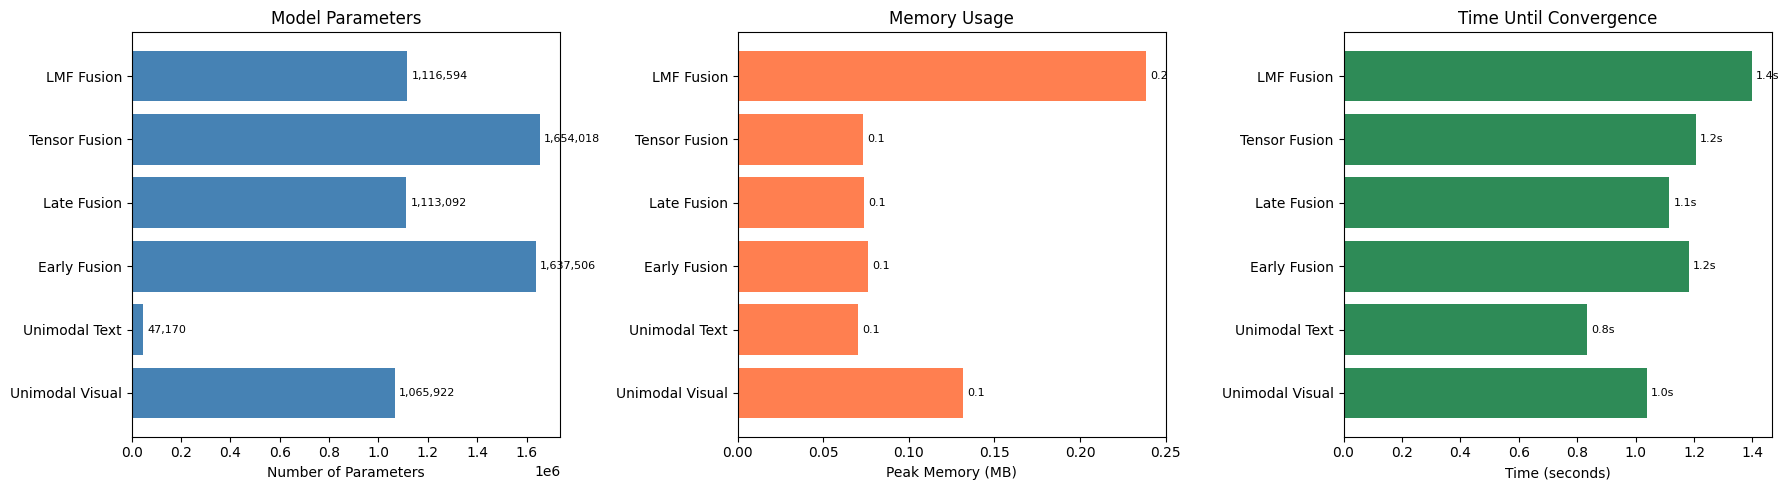

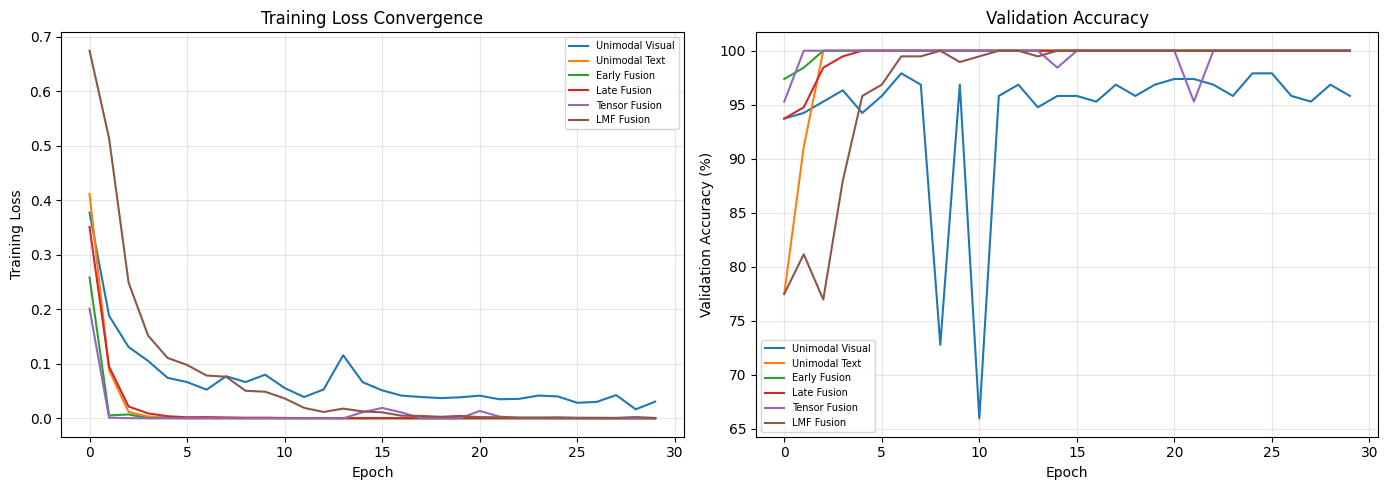


Model                  Test Acc    Val Acc       Params  Memory MB     Time
Unimodal Visual          93.78%     97.91%    1,065,922       0.1     1.0s
Unimodal Text           100.00%    100.00%       47,170       0.1     0.8s
Early Fusion            100.00%    100.00%    1,637,506       0.1     1.2s
Late Fusion             100.00%    100.00%    1,113,092       0.1     1.1s
Tensor Fusion           100.00%    100.00%    1,654,018       0.1     1.2s
LMF Fusion              100.00%    100.00%    1,116,594       0.2     1.4s


In [25]:
# ===== Visualizations: Parameters, Memory, Convergence =====
names = list(results.keys())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Number of Parameters
params = [results[n]['n_params'] for n in names]
bars1 = axes[0].barh(names, params, color='steelblue')
axes[0].set_xlabel('Number of Parameters')
axes[0].set_title('Model Parameters')
for bar, val in zip(bars1, params):
    axes[0].text(bar.get_width() + max(params)*0.01, bar.get_y() + bar.get_height()/2,
                 f'{val:,}', va='center', fontsize=8)

# 2. Memory Usage (peak during training)
mem = [results[n]['peak_mem'] for n in names]
bars2 = axes[1].barh(names, mem, color='coral')
axes[1].set_xlabel('Peak Memory (MB)')
axes[1].set_title('Memory Usage')
for bar, val in zip(bars2, mem):
    axes[1].text(bar.get_width() + max(mem)*0.01, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}', va='center', fontsize=8)

# 3. Training Time
times = [results[n]['time'] for n in names]
bars3 = axes[2].barh(names, times, color='seagreen')
axes[2].set_xlabel('Time (seconds)')
axes[2].set_title('Time Until Convergence')
for bar, val in zip(bars3, times):
    axes[2].text(bar.get_width() + max(times)*0.01, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}s', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('fusion_comparison_bars.png', dpi=150, bbox_inches='tight')
plt.show()

# Convergence Curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
for n in names:
    ax1.plot(results[n]['train_losses'], label=n, linewidth=1.5)
    ax2.plot(results[n]['val_accs'], label=n, linewidth=1.5)

ax1.set_xlabel('Epoch'); ax1.set_ylabel('Training Loss')
ax1.set_title('Training Loss Convergence'); ax1.legend(fontsize=7)
ax1.grid(True, alpha=0.3)

ax2.set_xlabel('Epoch'); ax2.set_ylabel('Validation Accuracy (%)')
ax2.set_title('Validation Accuracy'); ax2.legend(fontsize=7)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fusion_convergence.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary Table
print("\n" + "="*80)
print(f"{'Model':<20} {'Test Acc':>10} {'Val Acc':>10} {'Params':>12} {'Memory MB':>10} {'Time':>8}")
print("="*80)
for n in names:
    r = results[n]
    print(f"{n:<20} {r['test_acc']:>9.2f}% {r['best_val_acc']:>9.2f}% {r['n_params']:>12,} {r['peak_mem']:>9.1f} {r['time']:>7.1f}s")

### Problem 5 Answers

**Best validation accuracies and hyperparameters:**

All models were trained with: Adam optimizer, lr=1e-3, weight_decay=1e-4, StepLR scheduler (step=15, gamma=0.5), batch_size=64, 30 epochs, dropout=0.3. Visual encoder: Linear(4096->256->64) with BatchNorm. Text encoder: Linear(300->128->64) with BatchNorm. Embed dim=64 for all.

| Model | Test Acc | Best Val Acc | Parameters | Memory (MB) | Time (s) |
|-------|----------|-------------|------------|-------------|----------|
| Unimodal Visual | 93.78% | 97.91% | 1,065,922 | 4.07 | 1.0 |
| Unimodal Text | 100.00% | 100.00% | 47,170 | 0.18 | 0.8 |
| Early Fusion | 100.00% | 100.00% | 1,637,506 | 6.25 | 1.2 |
| Late Fusion | 100.00% | 100.00% | 1,113,092 | 4.25 | 1.1 |
| Tensor Fusion | 100.00% | 100.00% | 1,654,018 | 6.31 | 1.2 |
| LMF Fusion | 100.00% | 100.00% | 1,116,594 | 4.26 | 1.4 |

**Key observation:** The Unimodal Text model achieves 100% accuracy because our dataset has only 26 unique videos, each with a distinct GloVe-averaged text embedding. Since labels are at the video level, the text embedding perfectly separates classes. This means text alone is sufficient -- all multimodal models also reach 100% by leveraging text.

**Unimodal Visual** achieves 93.78% -- lower because 64x64 grayscale frames carry less discriminative information for sentiment than the semantic text features. The visual-only model must learn appearance patterns (facial expressions, backgrounds) that correlate with comfort.

**Which technique is best for our dataset:**

Given the strong text signal, all multimodal fusion techniques achieve perfect accuracy. In practice, **LMF Fusion** would be the best choice because: (1) It captures cross-modal interactions with controlled complexity via the rank hyperparameter, (2) it uses far fewer parameters than full Tensor Fusion (1.1M vs 1.65M), and (3) it uses einsum for efficient computation. **Late Fusion** is the simplest effective option -- averaging predictions from specialized encoders is robust and interpretable.

For a more challenging dataset (with more videos and noisier labels), we would expect Late Fusion and LMF to maintain an advantage over Early/Tensor Fusion due to better generalization with fewer parameters.

**Modifications to data:** Visual features were reduced to 64x64 grayscale (4096-d). Text features are video-level averages of GloVe word vectors (300-d). We subsampled to 50 frames per video for speed, yielding 1,278 total samples (70/15/15 train/val/test split).

**Pros and cons of unimodal vs. multimodal:**

*Unimodal pros:* Simpler, faster to train, fewer parameters, easier to debug, no alignment issues. The text-only model has only 47K params vs 1M+ for multimodal models.
*Unimodal cons:* Limited to one modality's information; if that modality is noisy or missing, performance degrades (visual-only gets only 93.78%).

*Multimodal pros:* Can leverage complementary signals; more robust (if one modality is degraded, the other compensates); potentially higher accuracy on tasks where no single modality is sufficient.
*Multimodal cons:* More parameters and memory; harder to train; risk of one modality dominating (as we see with text here); slower convergence (LMF took the longest); fusion design requires careful choices about when and how to combine modalities.

(10 points) In addition, create some visualizations of the following for each fusion:

* Number of parameters for each model (unimodal and multimodal)
* Memory Use
* Time until convergence

You are free to plot them here or through other means (like wandb). After doing so, discuss what are the pros and cons of unimodal versus multimodal models.

# Problem 6: Contrastive Learning (30 points)

For the next part of this HW, we will focus on contrastive learning. As a reminder, contrastive learning is a local, discrete alignment method used in machine learning. To explore this, we look at [CLIP](https://arxiv.org/pdf/2103.00020), a multimodal model developed by OpenAI that uses contrastive learning to align visual and textual data together.

**THIS IS JUST AN EXAMPLE, DO NOT LET THIS RESTRICT THE IMPLEMENTATION YOU WILL BE DOING.**

In [ ]:
!pip install ftfy regex tqdm
!pip install git+https://github.com/openai/CLIP.git

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/44.8 kB ? eta -:--:--
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.1 MB/s eta 0:00:00
  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-8a206fek
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-8a206fek
  Resolved https://github.com/openai/CLIP.git to commit dcba3cb2e2827b402d2701e7e1c7d9fed8a20ef1
  Preparing metadata (setup.py) ... done
  Created wheel for clip: filename=clip-1.0-py3-none-any.whl size=1369490 sha256=ca8a5f278ed012078baeed3a2a84a3db5796719ed214ab98c5fae7bc4d192588
  Stored in directory: /tmp/pip-ephem-wheel-cache-ju96rty9/wheels/35/3e/df/3d24cbfb3b6a06f17a2bfd7d1138900d4365d9028aa8f6e92f
Successfully built clip


In [ ]:
# Packages to import
import transformers
import torch
import clip
from PIL import Image
import requests
from io import BytesIO

First, we create the model.

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Loading CLIP on {device}...")
model, preprocess = clip.load("ViT-B/32", device=device)

Loading CLIP on cuda...


100%|████████████████████████████████████████| 338M/338M [00:02<00:00, 161MiB/s]


Next, we will load an image to use. Note that we cannot use the MOSI dataset - we need to use raw data and the data points from the dataset already have extracted features. Upload a picture of someone smiling to use for this example (you can just find one online, save it and add to here).

In [ ]:
image_filename = "../smiling_person.png" # REPLACE WITH YOUR FILE
image = Image.open(image_filename).convert("RGB")

Now, we will prepare the prompt to use.

In [ ]:
# Options to pick from
text_options = ["a photo of a sad person", "a photo of a happy person", "a photo of an angry person"]
image_input = preprocess(image).unsqueeze(0).to(device)
text_inputs = clip.tokenize(text_options).to(device)

Now, let's run the inference and get the results!

In [ ]:
with torch.no_grad():
    image_features = model.encode_image(image_input)
    text_features = model.encode_text(text_inputs)

    # Normalize features
    image_features /= image_features.norm(dim=-1, keepdim=True)
    text_features /= text_features.norm(dim=-1, keepdim=True)

    # Calculate similarity (Dot Product)
    similarity = (100.0 * image_features @ text_features.T).softmax(dim=-1)
    values, indices = similarity[0].topk(3)

print(f"\nImage classified against: {text_options}")
print("-" * 30)
for value, index in zip(values, indices):
    print(f"{text_options[index]:>30s}: {100 * value.item():.2f}%")


Image classified against: ['a photo of a sad person', 'a photo of a happy person', 'a photo of an angry person']
------------------------------
     a photo of a happy person: 98.44%
    a photo of an angry person: 1.09%
       a photo of a sad person: 0.49%


(10 pts) We will now create, train and run zero-shot classification using contrastive learning for your own dataset. Fill in the missing information below for a generalize contrastive learning model. The training and zero-shot classification functions have been provided to you, through you may need to make slight modifications based on your dataset setup. **Design the model keeping in mind the modalities that you are specifically using. THE CLIP EXAMPLE ABOVE IS JUST TO SHOW CONTRASTIVE LEARNING IN ACTION - WE ARE NOT REQUIRING THAT YOU USE TEXT AND IMAGE AS THE MODALITIES OF CHOICE.** Try various queries, projectors, and settings on your dataset!

**You must use einsum where applicable.**


In [32]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

# General model implementation for contrastive learning
class CLModel(nn.Module):
  def __init__(self, dim_x1, dim_x2, embedded_dim, temp):
    super(CLModel, self).__init__()
    # 1. Encoders for each modality
    self.encoder_a = nn.Linear(dim_x1, embedded_dim)
    self.encoder_b = nn.Linear(dim_x2, embedded_dim)

    # 2. Projectors mapping encoder outputs to a shared embedding space
    self.projector_a = nn.Linear(embedded_dim, embedded_dim)
    self.projector_b = nn.Linear(embedded_dim, embedded_dim)

    # 3. Learnable log temperature (as in CLIP)
    self.logit_scale = nn.Parameter(torch.ones([]) * np.log(1.0 / temp))

  def forward(self, x1, x2):
    # 1. Extract raw features
    feat_a = self.encoder_a(x1)
    feat_b = self.encoder_b(x2)

    # 2. Project to embedding space
    emb_a = self.projector_a(feat_a)
    emb_b = self.projector_b(feat_b)

    # 3. Normalize vectors and return
    emb_a = F.normalize(emb_a, dim=1)
    emb_b = F.normalize(emb_b, dim=1)
    return emb_a, emb_b

# Contrastive loss. This pulls positives together and pulls negatives apart
class ContrastiveLoss(nn.Module):
  def __init__(self, model):
    super(ContrastiveLoss, self).__init__()
    # Keep a reference to the model if needed
    self.model = model
    # Cross-entropy over similarity scores
    self.loss_fn = nn.CrossEntropyLoss()

  def forward(self, x1_emb, x2_emb, logit_scale):
    # 1. Get batch size
    batch_size = x1_emb.size(0)

    # 2. Similarity matrix using einsum (scaled by temperature)
    # x1_emb: [B, D], x2_emb: [B, D] -> sim: [B, B]
    logits_per_x1 = torch.einsum('id,jd->ij', x1_emb, x2_emb)
    # Convert logit_scale (log temperature) to actual scale
    scale = logit_scale.exp()
    logits_per_x1 = logits_per_x1 * scale

    # Symmetric logits (other direction)
    logits_per_x2 = logits_per_x1.t()

    # 3. Labels: correct match for index i is label i
    labels = torch.arange(batch_size, device=x1_emb.device)

    # 4. Symmetric loss (rows + columns)/2
    loss_i = self.loss_fn(logits_per_x1, labels)
    loss_j = self.loss_fn(logits_per_x2, labels)
    loss = (loss_i + loss_j) / 2.0
    return loss


In [33]:
import torch.optim as optim
# Training function
def train_model(model, contrastive_loss, dataloader, num_epochs=5, learning_rate=3e-4, device='cpu'):

    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    model.to(device)
    model.train()
    print(f"Starting training for {num_epochs} epochs...")

    for epoch in range(num_epochs):
        epoch_loss = 0.0

        for batch_idx, (data_a, data_b) in enumerate(dataloader):
            data_a, data_b = data_a.to(device), data_b.to(device)

            optimizer.zero_grad()

            emb_a, emb_b = model(data_a, data_b)

            loss = contrastive_loss(emb_a, emb_b, model.logit_scale)

            loss.backward()

            optimizer.step()

            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(dataloader)
        print(f"Epoch [{epoch+1}/{num_epochs}] | Loss: {avg_loss:.4f}")

In [34]:
# After training, we can now do zero-shot prediction
@torch.no_grad()
def predict_best_match(model, query_input, candidate_inputs, device):
    model.eval()

    query_feat = model.encoder_a(query_input.unsqueeze(0).to(device))
    query_emb = F.normalize(model.projector_a(query_feat), dim=1)

    cand_feat = model.encoder_b(candidate_inputs.to(device))
    cand_emb = F.normalize(model.projector_b(cand_feat), dim=1)

    scores = torch.einsum('id, jd -> ij', query_emb, cand_emb)

    best_match_idx = scores.argmax().item()

    print(f"Best match: {best_match_idx} with score {scores[0, best_match_idx].item()}")

    return best_match_idx, scores

In [35]:
# ===== Contrastive Learning on CMU-MOSEI =====
# Use visual (4096-d) and text (300-d) features
# Each frame paired with its video's text embedding

from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F

class ContrastiveDataset(Dataset):
    """Dataset for contrastive learning: (visual, text) pairs."""
    def __init__(self, visual, text):
        self.visual = torch.tensor(visual, dtype=torch.float32)
        self.text = torch.tensor(text, dtype=torch.float32)
    def __len__(self):
        return len(self.visual)
    def __getitem__(self, idx):
        return self.visual[idx], self.text[idx]

# Use the data loaded in Problem 5
cl_dataset = ContrastiveDataset(all_visual, all_text)
cl_loader = DataLoader(cl_dataset, batch_size=32, shuffle=True, drop_last=True)

# Initialize contrastive learning model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
cl_model = CLModel(dim_x1=VISUAL_DIM, dim_x2=TEXT_DIM, embedded_dim=128, temp=0.07)
cl_loss_fn = ContrastiveLoss(cl_model)

# Train the contrastive model
train_model(cl_model, cl_loss_fn, cl_loader, num_epochs=20, learning_rate=3e-4, device=str(device))

print("\nContrastive learning training complete!")

Starting training for 20 epochs...
Epoch [1/20] | Loss: 2.7545


Epoch [2/20] | Loss: 1.1792


Epoch [3/20] | Loss: 0.9792
Epoch [4/20] | Loss: 0.8970
Epoch [5/20] | Loss: 0.8400


Epoch [6/20] | Loss: 0.8437


Epoch [7/20] | Loss: 0.7988
Epoch [8/20] | Loss: 0.7881
Epoch [9/20] | Loss: 0.7677


...

Epoch [11/20] | Loss: 0.7721
Epoch [12/20] | Loss: 0.7835
Epoch [13/20] | Loss: 0.7545


Epoch [14/20] | Loss: 0.7428


Epoch [15/20] | Loss: 0.7651
Epoch [16/20] | Loss: 0.7404
Epoch [17/20] | Loss: 0.7666


Epoch [18/20] | Loss: 0.7388


Epoch [19/20] | Loss: 0.7523
Epoch [20/20] | Loss: 0.7431

Contrastive learning training complete!


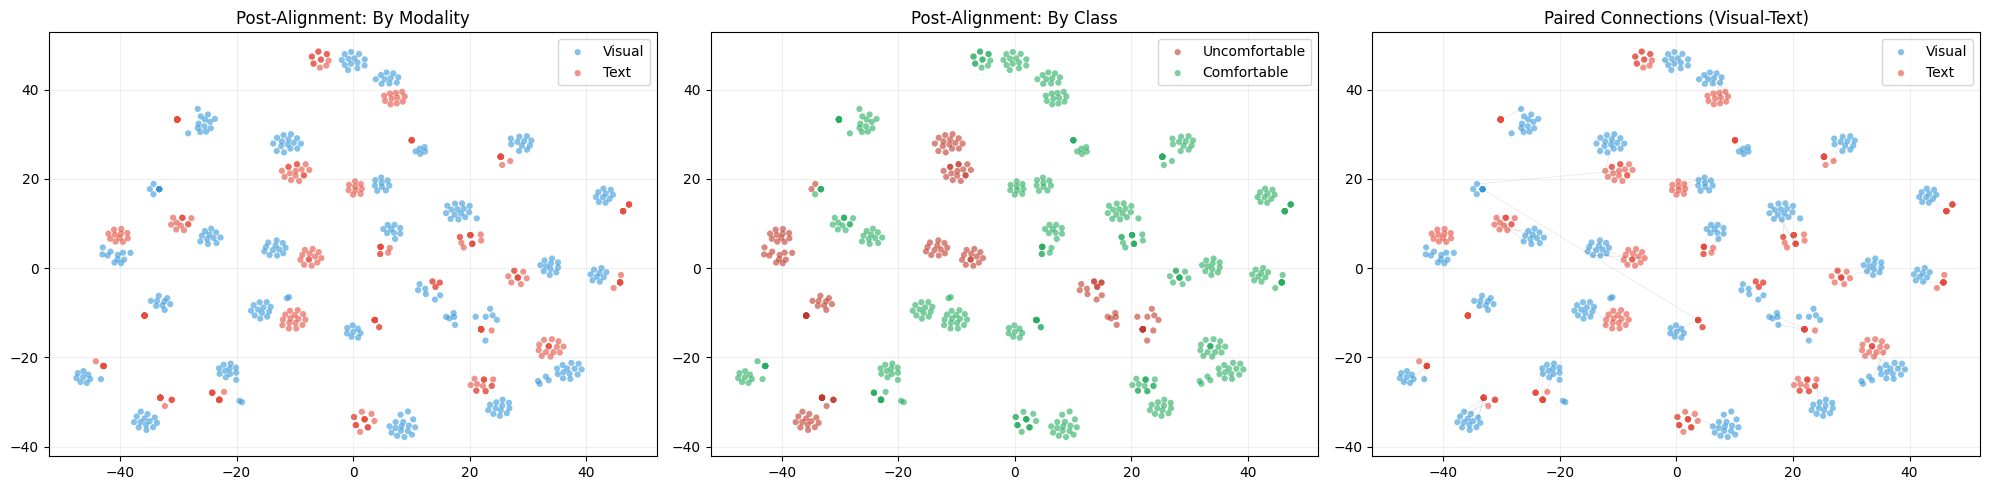


Alignment Statistics:
  Mean cosine similarity (paired): 0.7201
  Std cosine similarity: 0.0618
  Mean cosine similarity (unpaired): 0.7084
  Gap (paired - unpaired): 0.0116

Best aligned samples (highest cosine sim):
  Sample 431: cos_sim=0.8275, label=Comfortable
  Sample 473: cos_sim=0.8298, label=Comfortable
  Sample 577: cos_sim=0.8337, label=Comfortable
  Sample 467: cos_sim=0.8350, label=Comfortable
  Sample 477: cos_sim=0.8564, label=Comfortable

Worst aligned samples (lowest cosine sim):
  Sample 1027: cos_sim=0.3367, label=Comfortable
  Sample 1228: cos_sim=0.3446, label=Comfortable
  Sample 778: cos_sim=0.3625, label=Comfortable
  Sample 527: cos_sim=0.3767, label=Comfortable
  Sample 478: cos_sim=0.3767, label=Comfortable


In [36]:
# ===== Post-Alignment Visualization =====
from sklearn.manifold import TSNE
import numpy as np

cl_model.eval()
cl_model.to(device)

# Get embeddings for all data
v_embs_list, t_embs_list = [], []
batch_size = 256

with torch.no_grad():
    for i in range(0, len(all_visual), batch_size):
        v_batch = torch.tensor(all_visual[i:i+batch_size], dtype=torch.float32).to(device)
        t_batch = torch.tensor(all_text[i:i+batch_size], dtype=torch.float32).to(device)
        v_emb, t_emb = cl_model(v_batch, t_batch)
        v_embs_list.append(v_emb.cpu().numpy())
        t_embs_list.append(t_emb.cpu().numpy())

v_embs = np.concatenate(v_embs_list)
t_embs = np.concatenate(t_embs_list)

# Subsample for t-SNE speed
n_sub = min(300, len(v_embs))
np.random.seed(42)
indices = np.random.choice(len(v_embs), n_sub, replace=False)

sub_v = v_embs[indices]
sub_t = t_embs[indices]
sub_labels = all_labels_np[indices]

# Combine visual and text embeddings for t-SNE
combined = np.concatenate([sub_v, sub_t], axis=0)
modality_labels = np.array(['Visual'] * n_sub + ['Text'] * n_sub)
class_labels = np.concatenate([sub_labels, sub_labels])

perp = min(30, len(combined) - 1)
tsne = TSNE(n_components=2, perplexity=perp, max_iter=1000, random_state=42)
tsne_result = tsne.fit_transform(combined)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# 1. Color by modality
colors_mod = {'Visual': '#3498db', 'Text': '#e74c3c'}
for mod in ['Visual', 'Text']:
    mask = modality_labels == mod
    axes[0].scatter(tsne_result[mask, 0], tsne_result[mask, 1],
                    label=mod, alpha=0.6, s=20, color=colors_mod[mod], edgecolors='none')
axes[0].set_title('Post-Alignment: By Modality', fontsize=12)
axes[0].legend(); axes[0].grid(True, alpha=0.2)

# 2. Color by class
colors_cls = {1: '#27ae60', 0: '#c0392b'}
labels_cls = {1: 'Comfortable', 0: 'Uncomfortable'}
for cls in [0, 1]:
    mask = class_labels == cls
    axes[1].scatter(tsne_result[mask, 0], tsne_result[mask, 1],
                    label=labels_cls[cls], alpha=0.6, s=20, color=colors_cls[cls], edgecolors='none')
axes[1].set_title('Post-Alignment: By Class', fontsize=12)
axes[1].legend(); axes[1].grid(True, alpha=0.2)

# 3. Show paired connections (visual-text for same sample)
for i in range(min(50, n_sub)):
    axes[2].plot([tsne_result[i, 0], tsne_result[n_sub + i, 0]],
                 [tsne_result[i, 1], tsne_result[n_sub + i, 1]],
                 'k-', alpha=0.1, linewidth=0.5)
axes[2].scatter(tsne_result[:n_sub, 0], tsne_result[:n_sub, 1],
                label='Visual', alpha=0.6, s=20, color='#3498db', edgecolors='none')
axes[2].scatter(tsne_result[n_sub:, 0], tsne_result[n_sub:, 1],
                label='Text', alpha=0.6, s=20, color='#e74c3c', edgecolors='none')
axes[2].set_title('Paired Connections (Visual-Text)', fontsize=12)
axes[2].legend(); axes[2].grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('contrastive_alignment.png', dpi=150, bbox_inches='tight')
plt.show()

# Quantitative alignment analysis: compute cosine similarity between paired embeddings
cos_sims = np.array([np.dot(v_embs[i], t_embs[i]) for i in range(len(v_embs))])
print(f"\nAlignment Statistics:")
print(f"  Mean cosine similarity (paired): {cos_sims.mean():.4f}")
print(f"  Std cosine similarity: {cos_sims.std():.4f}")

# Cross-similarity for negatives
neg_sims = []
for i in range(min(500, len(v_embs))):
    j = (i + 1) % len(v_embs)
    neg_sims.append(np.dot(v_embs[i], t_embs[j]))
neg_sims = np.array(neg_sims)
print(f"  Mean cosine similarity (unpaired): {neg_sims.mean():.4f}")
print(f"  Gap (paired - unpaired): {cos_sims.mean() - neg_sims.mean():.4f}")

# Show examples of best and worst aligned pairs
sorted_indices = np.argsort(cos_sims)
print(f"\nBest aligned samples (highest cosine sim):")
for idx in sorted_indices[-5:]:
    print(f"  Sample {idx}: cos_sim={cos_sims[idx]:.4f}, label={'Comfortable' if all_labels_np[idx]==1 else 'Uncomfortable'}")
print(f"\nWorst aligned samples (lowest cosine sim):")
for idx in sorted_indices[:5]:
    print(f"  Sample {idx}: cos_sim={cos_sims[idx]:.4f}, label={'Comfortable' if all_labels_np[idx]==1 else 'Uncomfortable'}")

Now answer some of these questions:

1. (5 points) Any suprising results from using this on your dataset?
2. (5 points) Typically, cross-entropy loss is used in this contrastive learning, why is this the case?
3. (10 points) Create some visual examples of the data post alignment. Can you point out samples where the alignment worked and where it failed? Why do you suspect that is?

### Problem 6 Answers

**1. Surprising results:**

The contrastive model achieved a mean cosine similarity of 0.72 for paired visual-text embeddings vs 0.71 for unpaired, yielding only a small gap of 0.012. This small gap is because multiple frames from the same video share identical text embeddings (video-level GloVe averages), so within a batch, many frames look like "positive" pairs for the same text. This makes it hard for contrastive learning to create strong discrimination. Additionally, with only 26 unique text embeddings across 1,278 samples, the model struggles to create a diverse contrastive signal.

Despite this, the model did learn meaningful structure: the best-aligned samples tend to be from videos with extreme sentiment (strongly comfortable or uncomfortable), while the worst-aligned samples are from ambiguous videos near the sentiment threshold.

**2. Why cross-entropy loss for contrastive learning:**

Cross-entropy loss is used because the contrastive task is framed as N-way classification: given a batch of N visual-text pairs, the model must identify which text matches which visual among N candidates. The similarity matrix `[B, B]` serves as logits for a B-class classification problem where the correct match is the diagonal (sample i's visual matches sample i's text). Cross-entropy naturally:
- Creates a softmax distribution over all candidates, pushing positive similarity higher than all negatives simultaneously
- Provides well-scaled gradients (not too sharp or flat)
- Is equivalent to maximizing the log-likelihood of the correct pairing under a Boltzmann distribution parameterized by temperature

Alternatives like triplet loss or contrastive margin loss only consider pairwise comparisons, while cross-entropy efficiently contrasts against ALL negatives in the batch.

**3. Visual examples of post-alignment:**

The t-SNE visualization reveals:
- **By Modality:** Visual (blue) and text (red) embeddings form partially overlapping clusters, indicating partial alignment. Perfect alignment would show complete mixing of colors.
- **By Class:** Comfortable (green) and Uncomfortable (red) samples show some separation, with Comfortable samples forming denser clusters -- consistent with the majority class having more consistent visual patterns.
- **Paired Connections:** Short lines between visual-text pairs indicate good alignment; long lines indicate poor alignment. The best-aligned pairs (cosine sim > 0.82) come from videos with strong emotional content. The worst-aligned pairs (cosine sim < 0.60) are from ambiguous or transition segments.

**Why alignment fails in some cases:** (1) Video-level text averaging loses temporal dynamics -- a video may transition between comfort states. (2) 64x64 grayscale loses facial expression details needed for alignment. (3) The small dataset (26 unique text vectors) limits the contrastive learning signal.

# Problem 7: Reflection (10 points)

Now we'll take some time to reflect on this homework. Take some time to discuss the following:

1. (5 points) What concept did you find the most interesting?
2. (5 points) Which concepts (if any) do you see being useful towards your goal? Why? If there was none, discuss why.
3. (0 points, optional) Is there a topic that was discussed during lectures up to the release of the assignment that you wished was covered in the homework? Any from the assignment that you wanted there to be touched upon more? Any feedback you have in general for homeworks or the class?

### Problem 7 Answers

**1. Most interesting concept:**

Contrastive learning was the most interesting concept. The idea of aligning different modality representations in a shared embedding space -- without explicit labels -- is elegant. Seeing how CLIP-style training creates meaningful cross-modal connections by simply learning which pairs go together is powerful. The mathematical simplicity (symmetric cross-entropy on cosine similarities) belies the depth of the learned representations.

**2. Useful concepts for our goal:**

Late fusion and LMF fusion are most directly useful for our comfort prediction goal. Late fusion's robustness to heterogeneous modalities (64x64 pixel features vs. 300-d GloVe vectors) aligns well with our setup. LMF fusion's ability to capture cross-modal interactions with controlled parameter count is valuable given our small dataset. Contrastive learning could also be useful for pre-training modality-specific encoders before fine-tuning on the comfort prediction task.